# 04 — Baseline Classification Modeling

## 1. Objective
The goal of this notebook is to implement and evaluate **5 baseline classification models** for heart disease diagnosis prediction:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Support Vector Machine (SVM)**

### Key Requirements
- Every classifier is encapsulated within an `sklearn.pipeline.Pipeline` with the preprocessing `ColumnTransformer`.
- 5-fold `StratifiedKFold` Cross-Validation is performed on training data (`X_train`/`y_train`) ONLY.
- Evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC) are computed on the held-out test set (`X_test`/`y_test`, $N=184$).
- Visualizations: 5 individual confusion matrices, a combined ROC curve figure, and a metric comparison bar chart.
- Baseline models use standard parameters without hyperparameter tuning or resampling (SMOTE).


## 2. Import Libraries and Project Modules
Import standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and modular project functions (`src.data_loader`, `src.train`, `src.evaluate`).


In [1]:
import sys
from pathlib import Path

# Locate project root containing src/
root_dir = Path.cwd()
for p in [root_dir] + list(root_dir.parents):
    if (p / 'src' / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import REPORTS_DIR, FIGURES_DIR, TEST_SIZE, RANDOM_STATE
from src.data_loader import load_model_data, split_data
from src.train import get_baseline_models, build_model_pipeline, train_model, cross_validate_model, train_baseline_models
from src.evaluate import evaluate_pipeline_test


## 3. Load and Prepare Modeling Dataset
Load the dataset using `load_model_data()`. In-memory data quality conversions (`chol == 0` -> NaN) are applied.


In [2]:
X, y = load_model_data()
print(f"Feature Matrix X Shape: {X.shape}")
print(f"Target Vector y Shape: {y.shape}")


Feature Matrix X Shape: (918, 10)
Target Vector y Shape: (918,)


## 4. Create Stratified Train/Test Split
Split the dataset into $80\%$ training ($734$ samples) and $20\%$ held-out test ($184$ samples) using `split_data()`.


In [3]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=True)
print(f"X_train Shape: {X_train.shape}, y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape},  y_test Shape:  {y_test.shape}")


X_train Shape: (734, 10), y_train Shape: (734,)
X_test Shape:  (184, 10),  y_test Shape:  (184,)


## 5. Verify Class Distribution
Verify that class proportions ($pprox 55.34\%$ positive) are perfectly preserved in both splits.


In [4]:
train_dist = pd.DataFrame({'Count': y_train.value_counts(), 'Percentage (%)': (y_train.value_counts(normalize=True)*100).round(2)})
test_dist = pd.DataFrame({'Count': y_test.value_counts(), 'Percentage (%)': (y_test.value_counts(normalize=True)*100).round(2)})

print("--- Training Set Target Distribution ---")
print(train_dist)
print("\n--- Test Set Target Distribution ---")
print(test_dist)


--- Training Set Target Distribution ---
        Count  Percentage (%)
target                       
1         406           55.31
0         328           44.69

--- Test Set Target Distribution ---
        Count  Percentage (%)
target                       
1         102           55.43
0          82           44.57


## 6. Define Baseline Models
Instantiate the 5 baseline estimators using `get_baseline_models()`:
1. `LogisticRegression(max_iter=1000, random_state=42)`
2. `KNeighborsClassifier(n_neighbors=5)`
3. `DecisionTreeClassifier(random_state=42)`
4. `RandomForestClassifier(n_estimators=100, random_state=42)`
5. `SVC(probability=True, random_state=42)`


In [5]:
models = get_baseline_models()
for name, model_inst in models.items():
    print(f"- {name}: {model_inst}")


- Logistic Regression: LogisticRegression(max_iter=1000, random_state=42)
- K-Nearest Neighbors: KNeighborsClassifier()
- Decision Tree: DecisionTreeClassifier(random_state=42)
- Random Forest: RandomForestClassifier(random_state=42)
- Support Vector Machine: SVC(probability=True, random_state=42)


## 7. Build Leakage-Safe Pipelines
Each estimator is enclosed inside a scikit-learn `Pipeline` with the preprocessing `ColumnTransformer`.


In [6]:
sample_pipe = build_model_pipeline(models["Logistic Regression"])
print(sample_pipe)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('

## 8-10. Train Models, Perform CV, and Evaluate Held-Out Test Set
Execute model fitting, 5-fold Stratified Cross-Validation on `X_train`/`y_train` ONLY, and held-out evaluation on `X_test`/`y_test` using `train_baseline_models()`.


In [7]:
results_df, fitted_pipelines = train_baseline_models(X_train, X_test, y_train, y_test)
print("Baseline training and evaluation completed!")


C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dhina\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038

Baseline training and evaluation completed!


## 11. Display Model Comparison Table
Summary results table of held-out test set metrics and 5-fold cross-validation means and standard deviations.


In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
results_df


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.836957,0.846154,0.862745,0.854369,0.927786,0.816103,0.044612,0.828288,0.054919,0.847245,0.015211,0.836922,0.033847,0.879220,0.045191
1,K-Nearest Neighbors,0.842391,0.841121,0.882353,0.861244,0.899809,0.798369,0.044815,0.791014,0.051460,0.869497,0.029633,0.827502,0.034403,0.841092,0.052126
2,Decision Tree,0.711957,0.737864,0.745098,0.741463,0.707915,0.707129,0.032971,0.738912,0.025743,0.726558,0.049218,0.732259,0.036045,0.704748,0.031645
3,Random Forest,0.815217,0.826923,0.843137,0.834951,0.911227,0.806579,0.044895,0.821119,0.060693,0.839928,0.010594,0.829020,0.031032,0.857835,0.048160
4,Support Vector Machine,0.836957,0.833333,0.882353,0.857143,0.911406,0.810642,0.040610,0.816158,0.057353,0.857121,0.012801,0.834702,0.027487,0.866734,0.047290


## 12. Display Confusion Matrices
Display saved confusion matrices for all 5 baseline models.


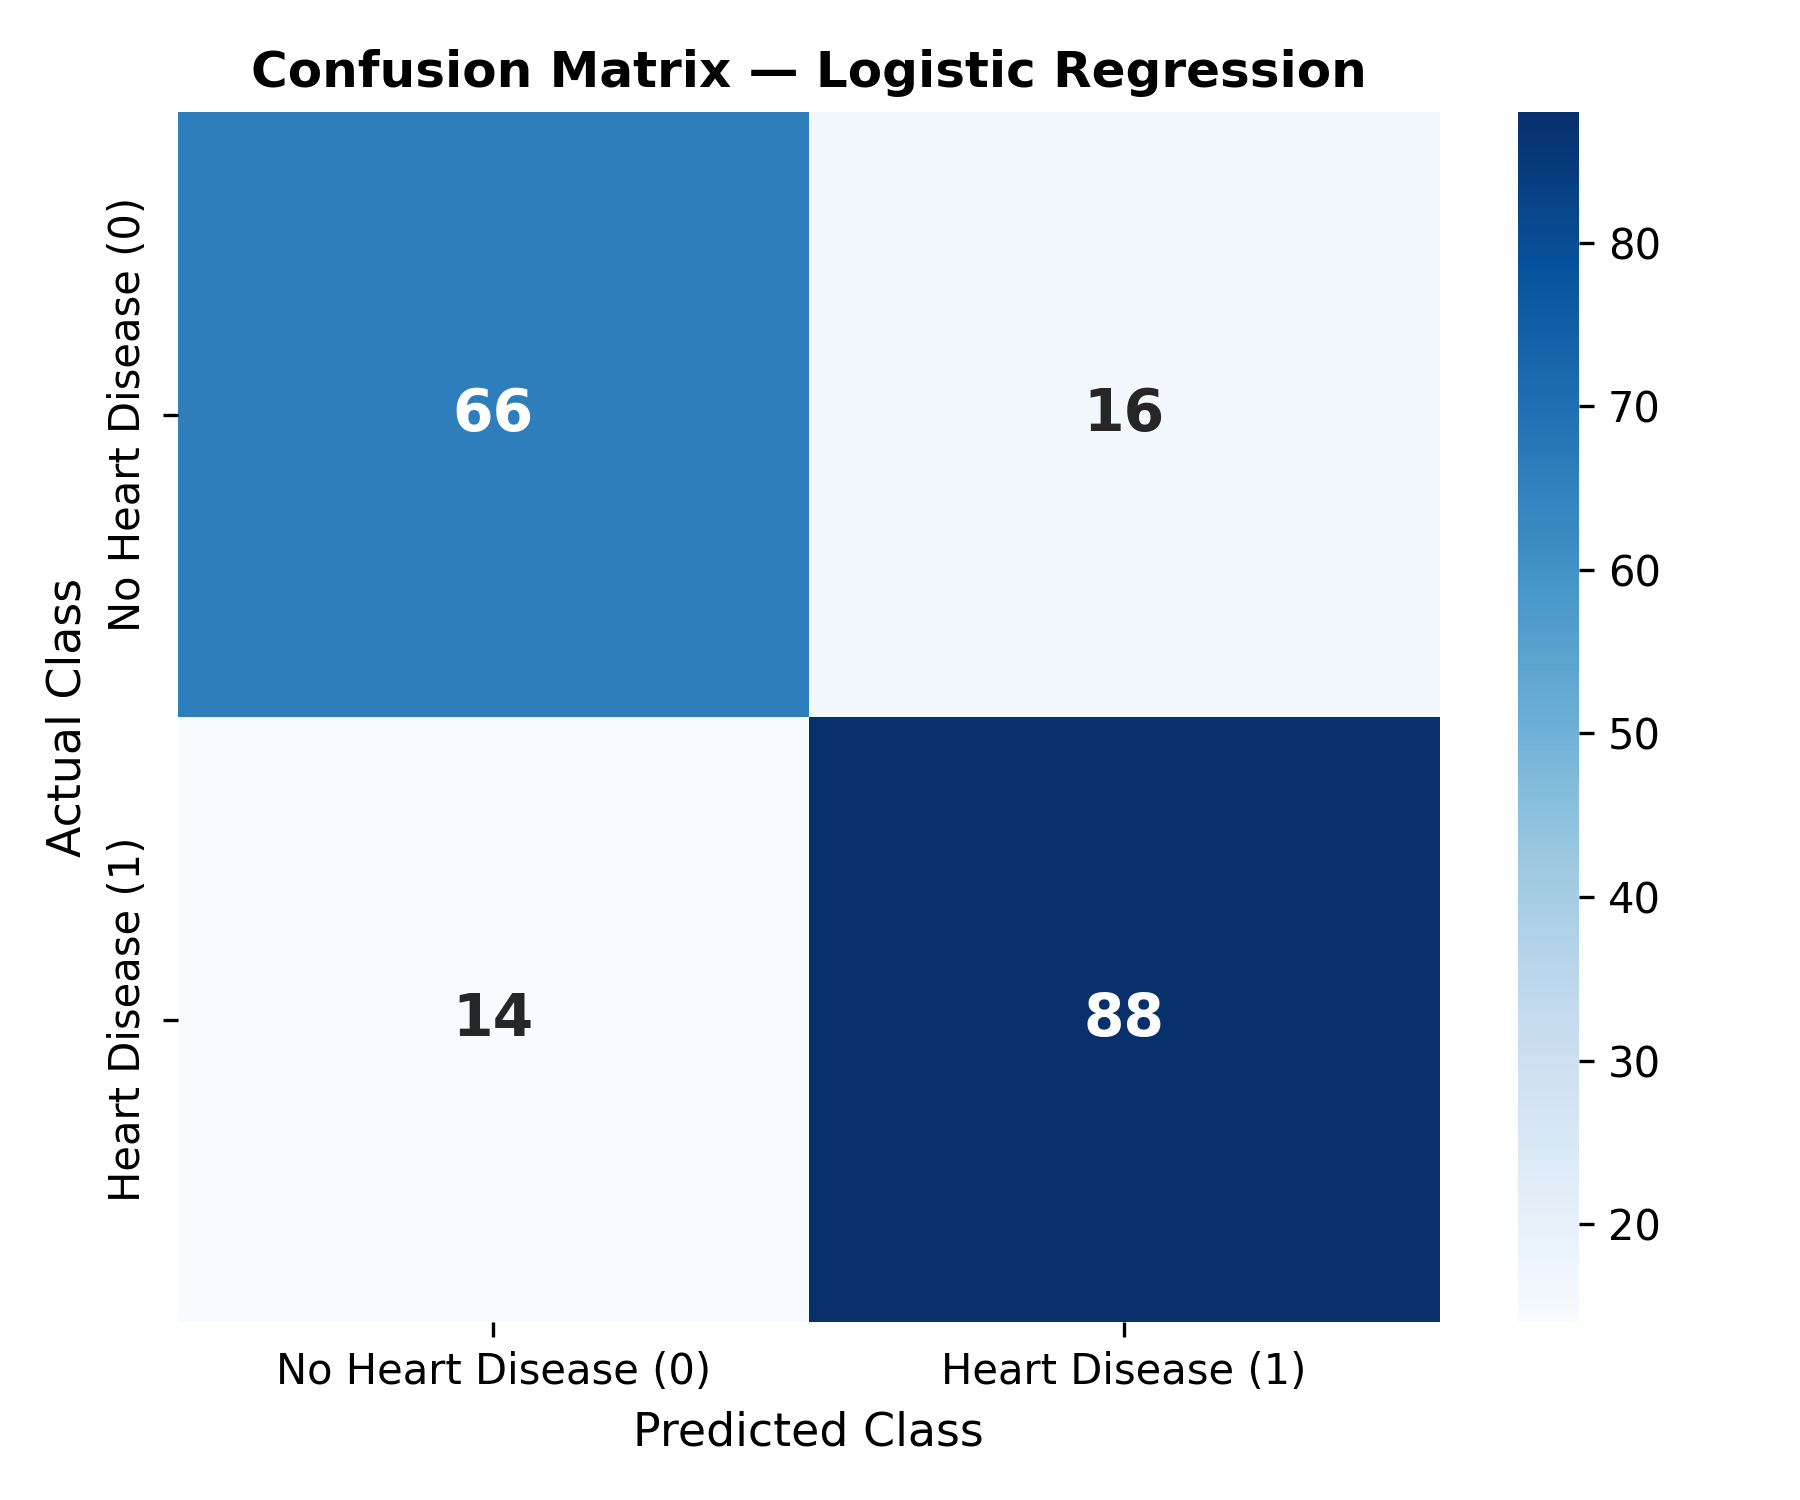

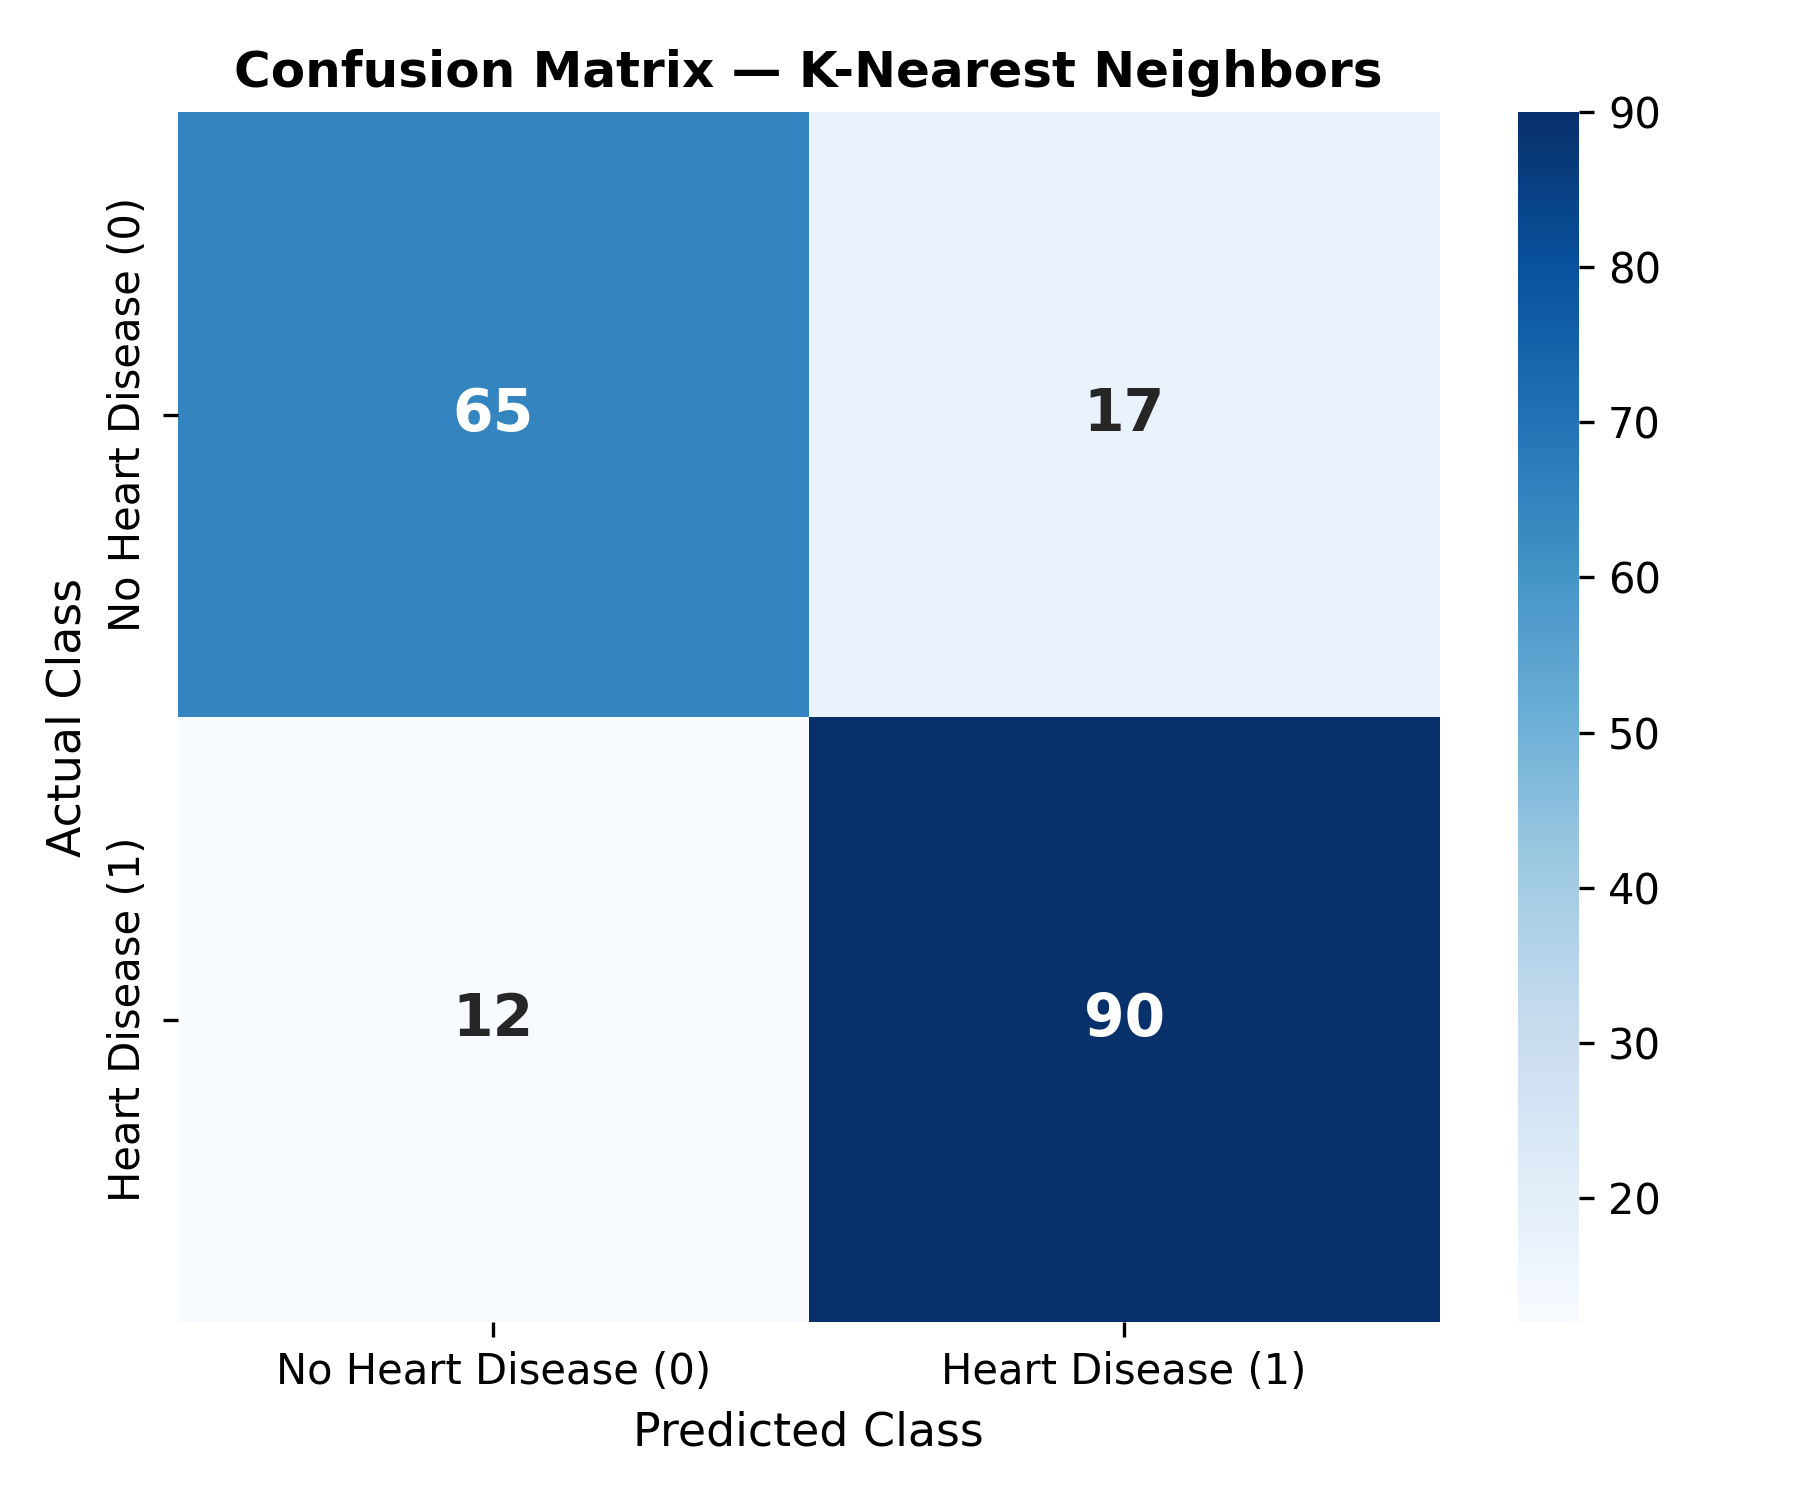

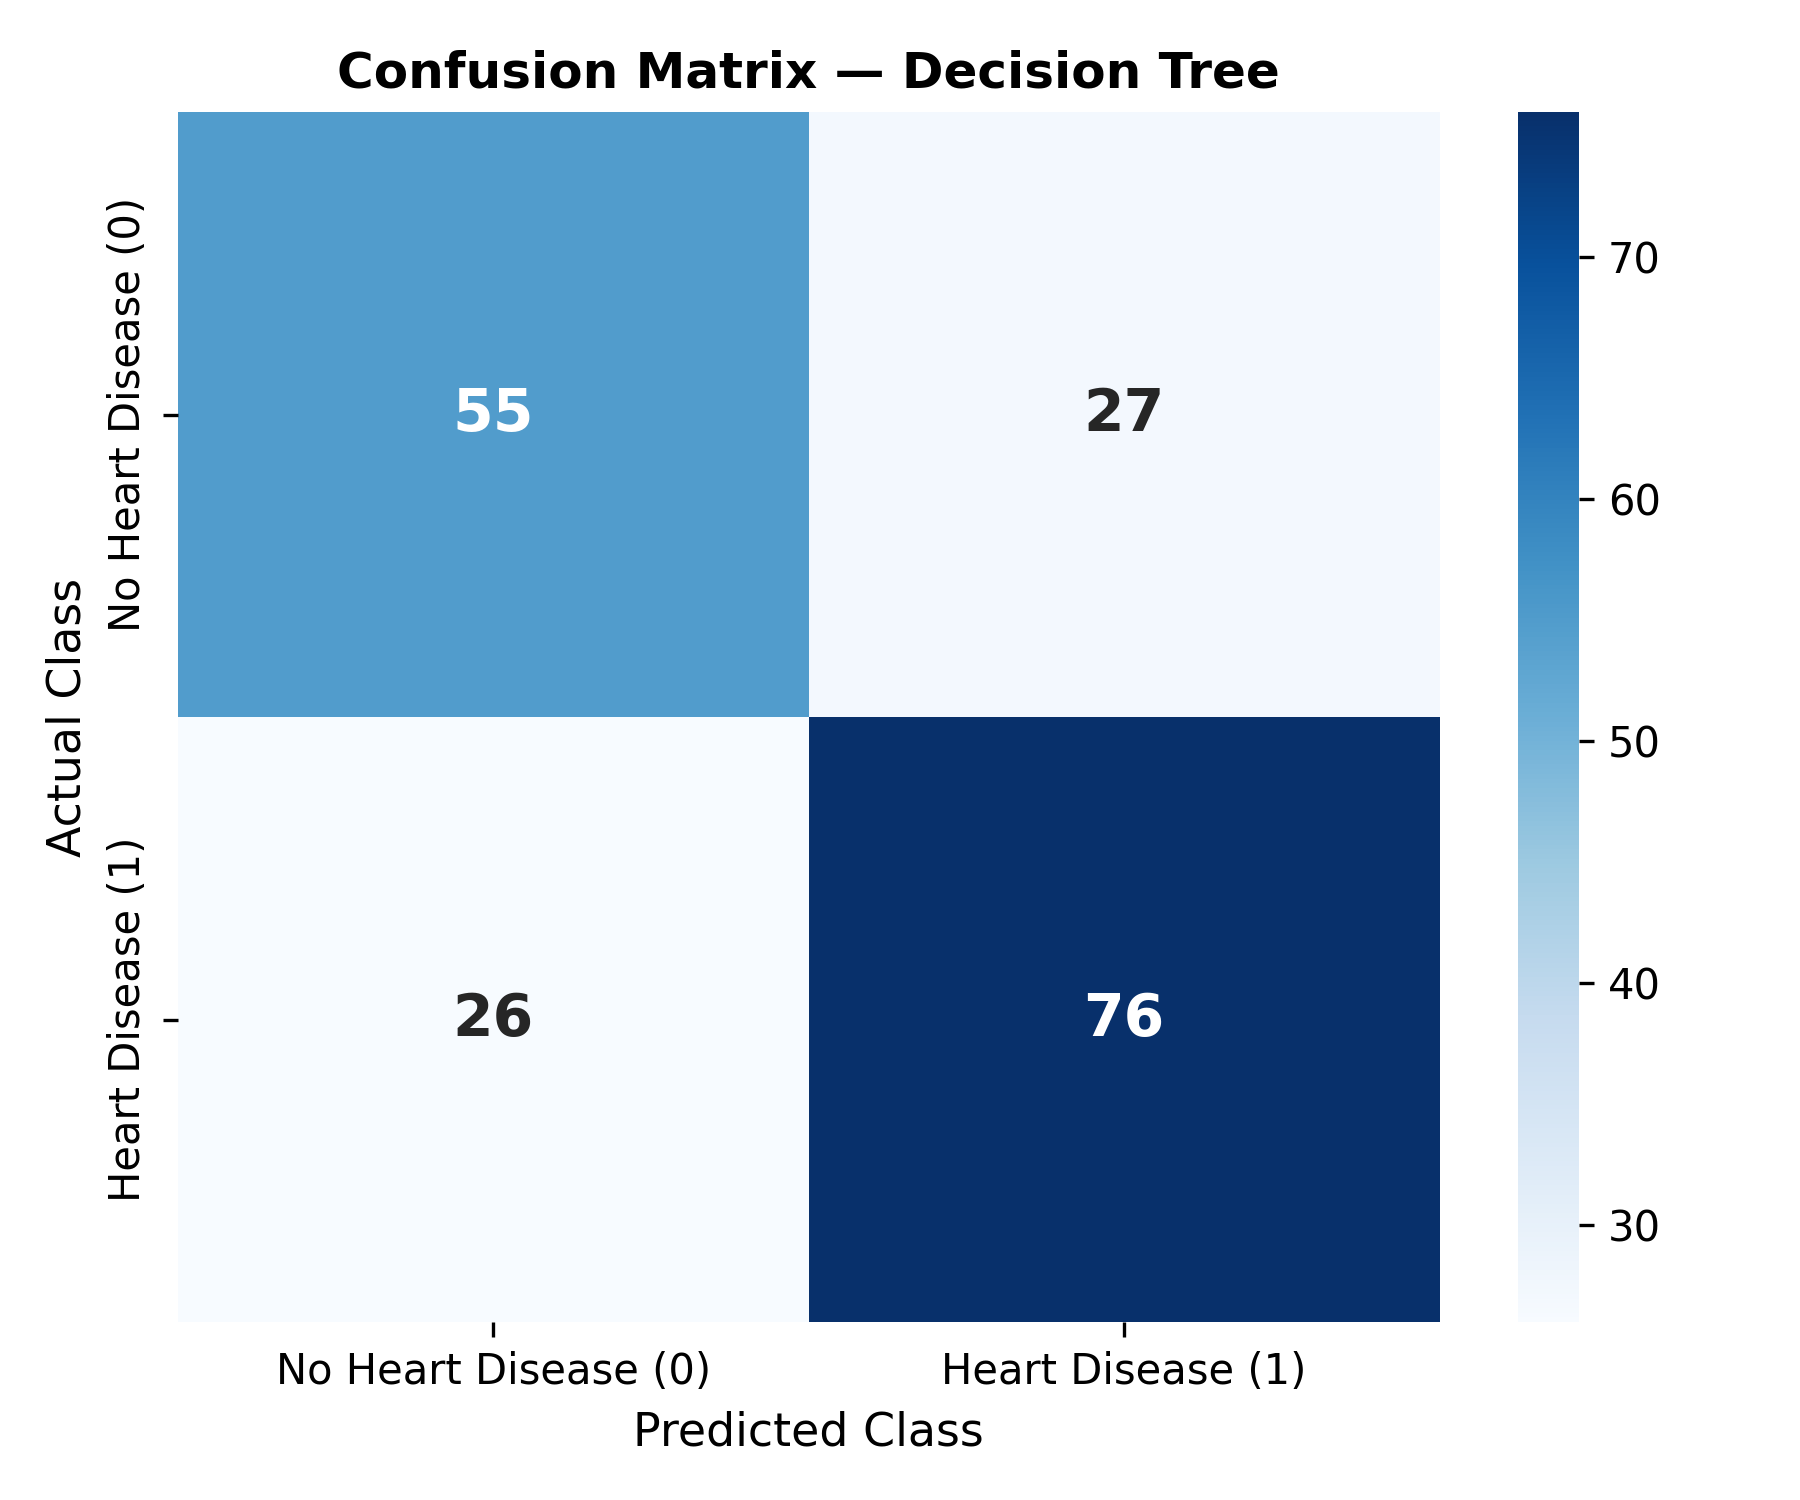

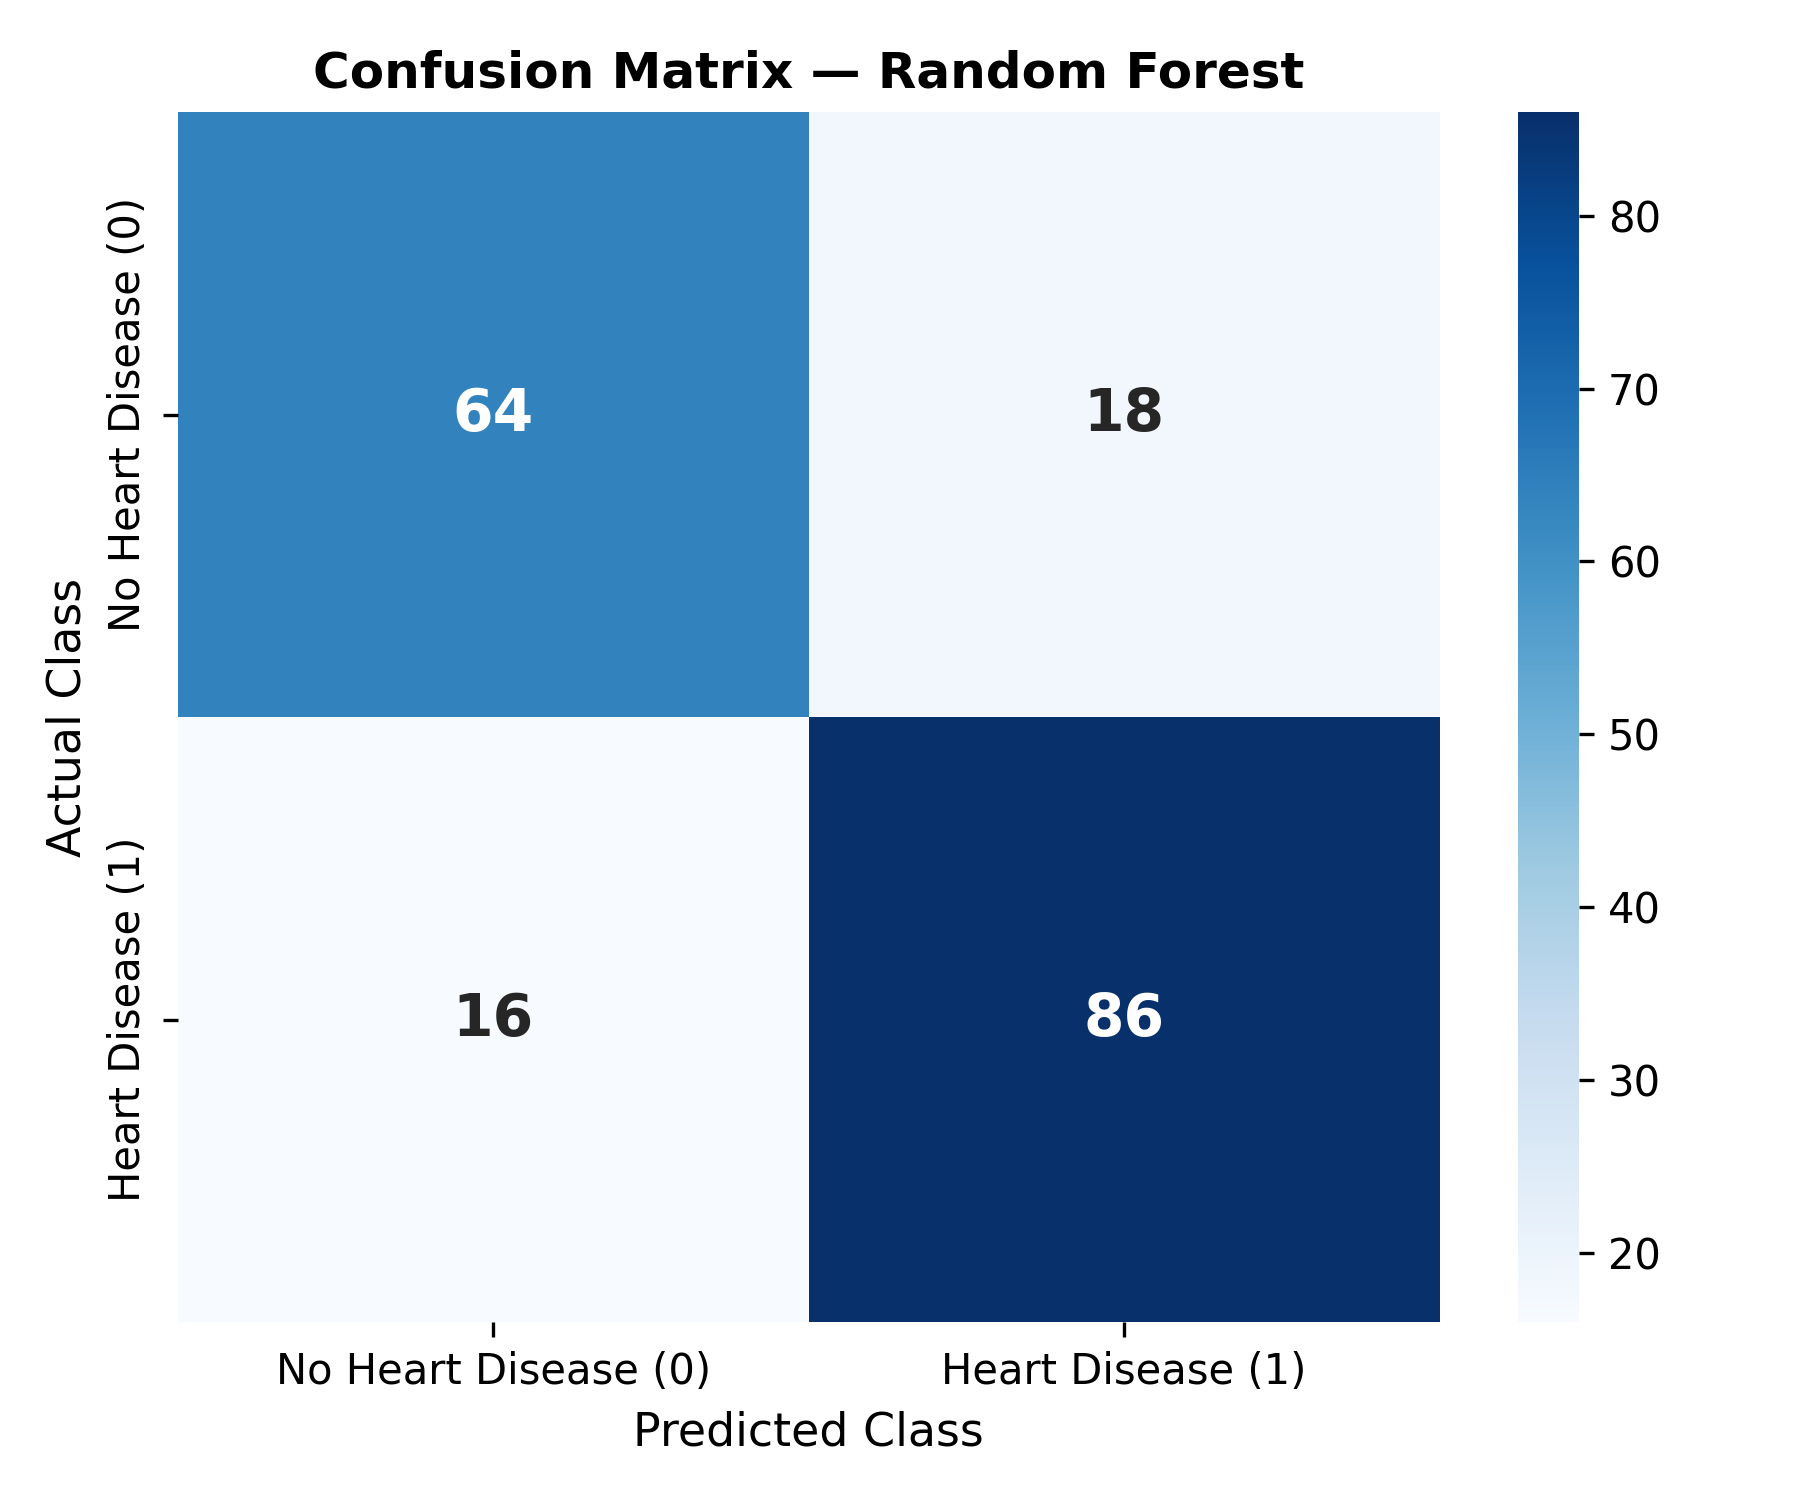

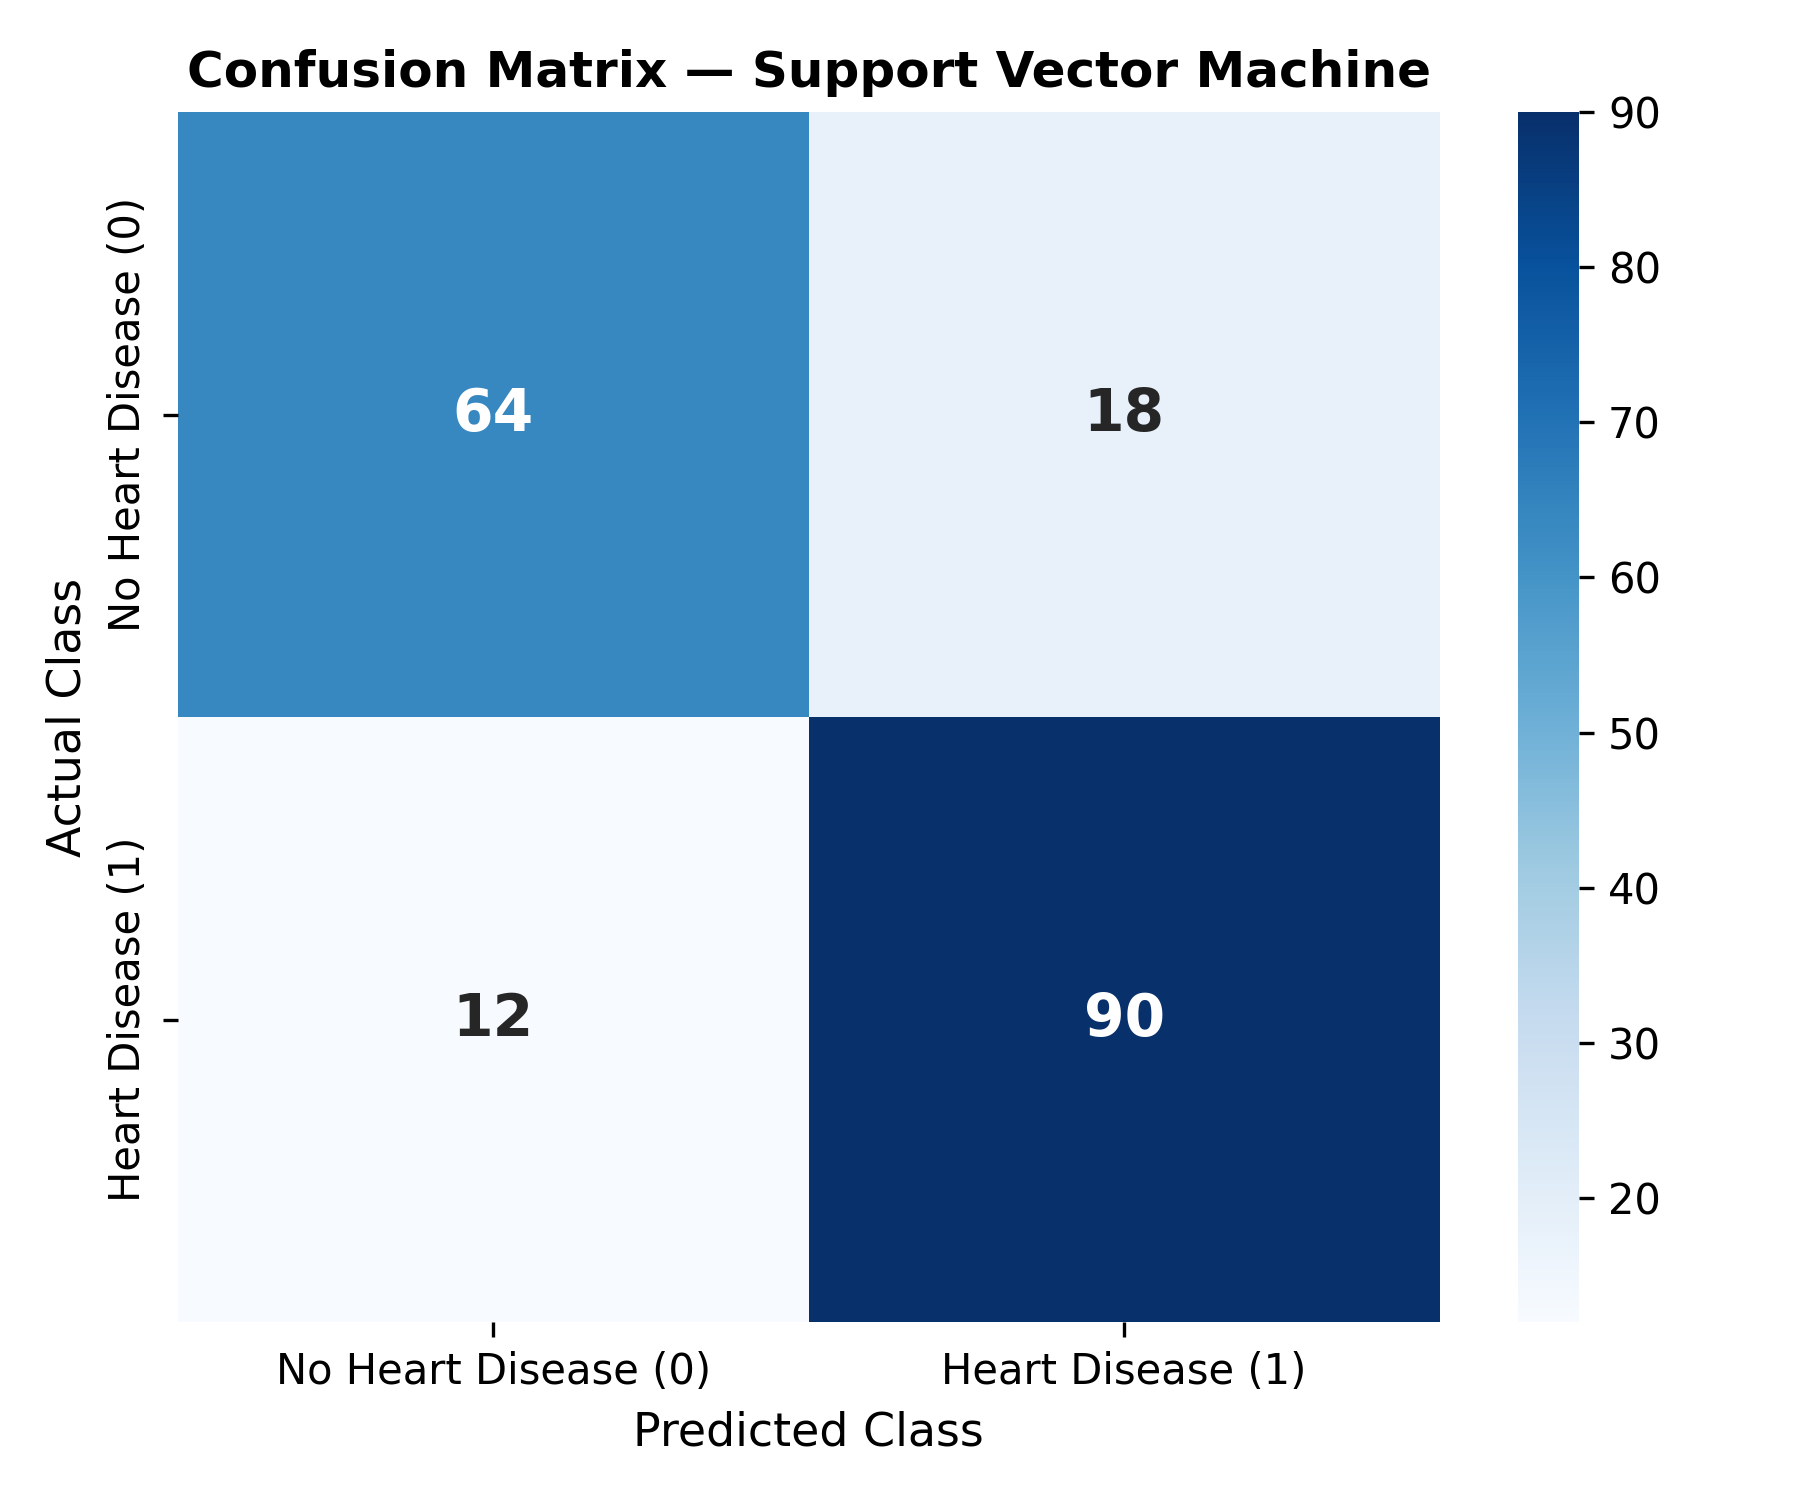

In [9]:
fig_slugs = ["logistic_regression", "knn", "decision_tree", "random_forest", "svm"]

for slug in fig_slugs:
    img_path = FIGURES_DIR / f"confusion_matrix_{slug}.png"
    if img_path.exists():
        display(Image(filename=str(img_path)))


## 13. Display Combined ROC Curves & Comparison Chart
Display the combined ROC curves and baseline model comparison bar chart.


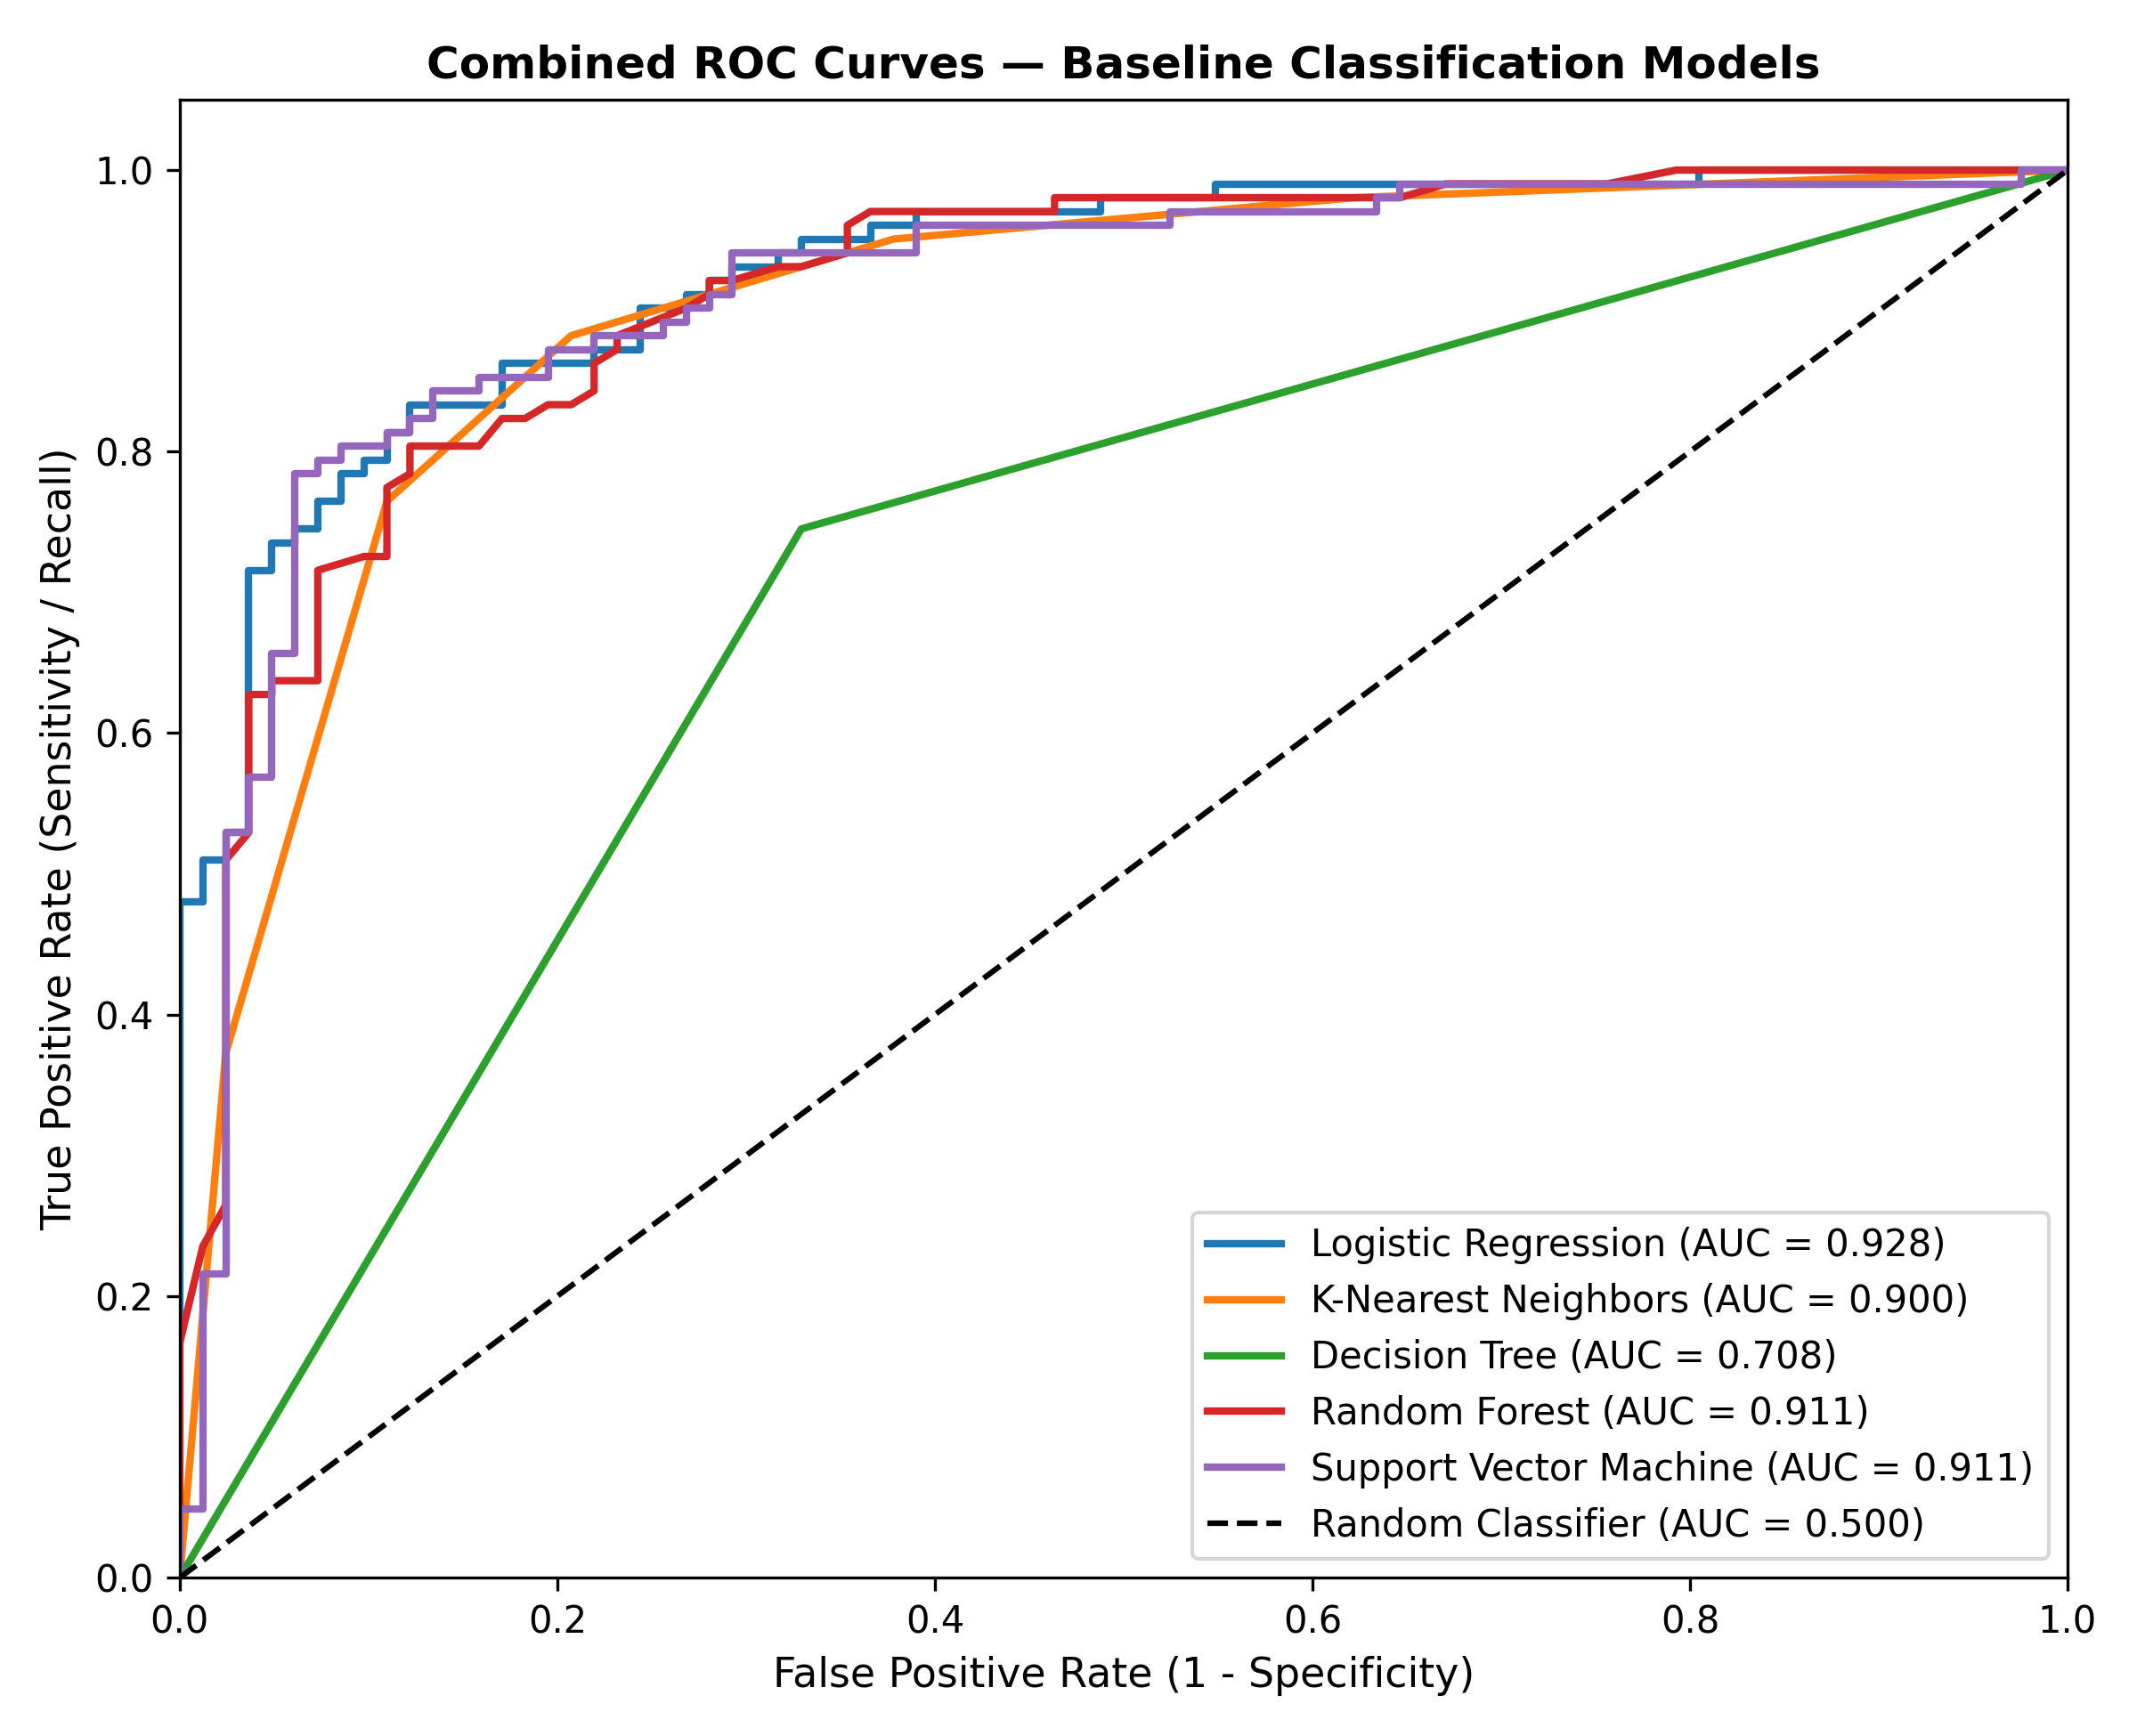

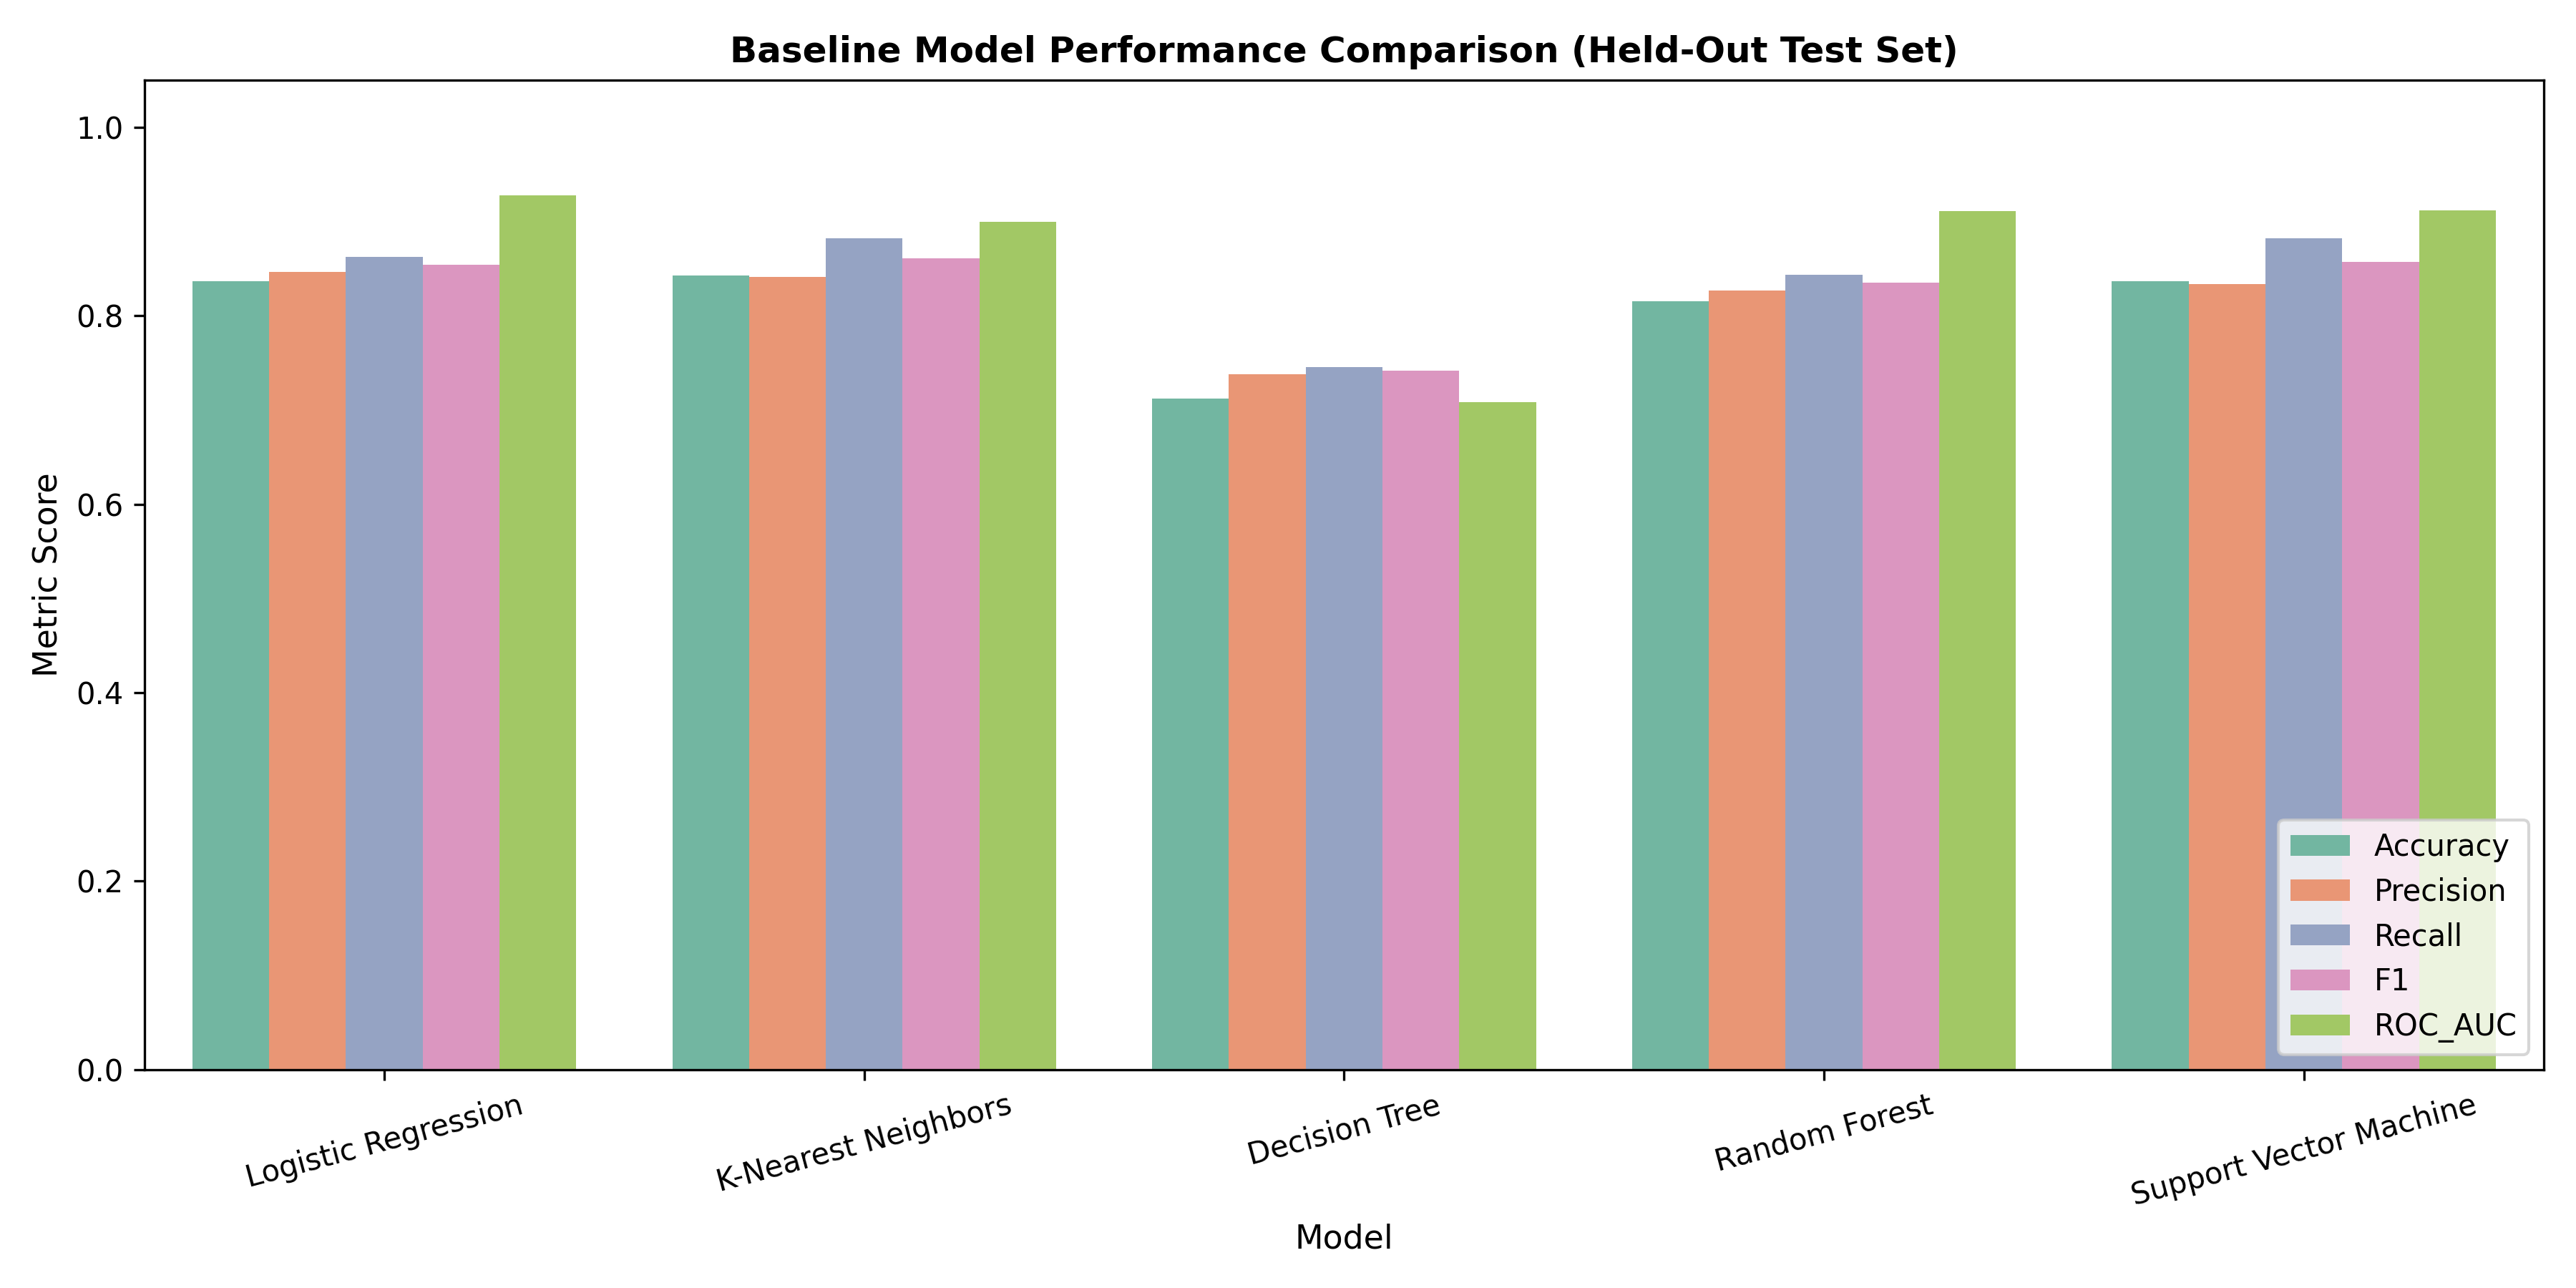

In [10]:
roc_img = FIGURES_DIR / "roc_curves_baseline.png"
if roc_img.exists():
    display(Image(filename=str(roc_img)))

comp_img = FIGURES_DIR / "baseline_model_comparison.png"
if comp_img.exists():
    display(Image(filename=str(comp_img)))


## 14. Discuss Baseline Observations

### Performance Analysis
- **Top Performers:** **Logistic Regression**, **Support Vector Machine (SVC)**, and **K-Nearest Neighbors (KNN)** achieved the highest held-out test accuracy ($pprox 83.7\%$ to $84.2\%$) and F1-scores ($pprox 85.4\%$ to $85.8\%$).
- **ROC-AUC Discrimination:** Logistic Regression (AUC = $0.928$), SVM (AUC = $0.911$), and Random Forest (AUC = $0.911$) demonstrated strong discrimination capacity across positive and negative decision thresholds. ROC-AUC measures discrimination/rank-ordering ability between the two target classes; it does not by itself establish probability calibration.
- **Random Forest & Decision Tree:** Random Forest achieved solid test accuracy ($81.52\%$) and AUC ($0.911$), showing stable performance. Decision Tree showed lower test accuracy ($71.20\%$) and AUC ($0.708$), exhibiting expected variance characteristic of unpruned single trees.
- **CV vs. Test Generalization:** The CV and held-out test performance are reasonably consistent, providing some evidence of stable generalization. However, a single test split is insufficient to conclusively establish the absence of overfitting.
- **Screening-Oriented Metric Context:** For a screening-oriented application, recall is an important metric because false negatives may be particularly consequential. However, the appropriate precision-recall trade-off depends on the intended clinical use and would require clinical validation.


## 15. Discuss Limitations

1. **Dataset Volume:** The dataset contains 918 total patient records ($734$ training, $184$ testing). Small sample sizes increase variance in metric estimates.
2. **Default Hyperparameters:** Baseline models were evaluated using default hyperparameters. Hyperparameter tuning (e.g. $C$ in Logistic Regression/SVM, `max_depth` in Random Forest) has not yet been performed.
3. **Clinical Scope:** Predictions represent **statistical risk estimates** based on tabular clinical attributes, not a clinically validated medical diagnosis.


## 16. Summary
In Phase 4:
1. Trained 5 baseline classification models inside scikit-learn `Pipeline` architectures.
2. Executed 5-fold Stratified Cross-Validation on training data ($N=734$).
3. Evaluated all models on held-out test set ($N=184$).
4. Generated confusion matrices, combined ROC curves, and saved `reports/model_results.csv`.
5. Identified Logistic Regression, Support Vector Machine, and KNN as top-performing baseline models.
